In [1]:
%pip install tqdm matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import rsa_oaep

In [3]:
(n, e, d) = rsa_oaep.generate_rsa_key()
message = "Ana are mere".encode()

ciphertext = rsa_oaep.rsa_oaep_encrypt(message, n, e)
print(f"Message: {message}")
print(f"Ciphertext: {ciphertext}")

Message: b'Ana are mere'
Ciphertext: b'Xm\x8f,\\\xc9_ga=X*\xd1Sc\xa4\x9bg[\x19\xb4\x80\xb0\x10\xc7\xd3\xab\xb0L&\xbc\xf6\x0b\xb4\xb7\x9c\xb4V\\_\xc8\xcf\xd0ISt4\xc6\xf8ORN\xfda\xce\xe3\xd8\x92U\xea\xf8\x12\xba\xe5\x9a\xbe\x16\xefM\x95\xa8\xb2\xb9I\x1f\x07\x9f0^CI\x0c\x85\x97\xd2kl\x7f\x10\xc4\xf1\x8e\x82\xc0\xae\x95\xe8\xaf\xcc\xb7\xa0\xac#P\xd2\xfb\x11\xad\x03<F@D\t\'\x97e\xcc\xfb{\xf1\xc5\xa8\xce\x92\xdb\xdc\xb6\x1f\xed\xaa\xc28/\x01\xc3H\xccV\x8f\xc1=\xdf[\x96\xeb%\x10\x84%\xa8^\xa7\xe5\xa7J\xc4\xe7\xb6K\xbb\xf1:x\xa1Y\xf3\'\xbe]Q\x04\x0c9R[v\xffc\x06\xae\xdf\xa6\x80FlF3D\x13xN\xda\x00\xb6\xee\xd13\xd9N\xb3\xec\xfd\xe0{j\xaf\xdb\xb5<\x8a\xbf\xf5\x156b\xb1\xa8\x10\xdc\xc4f@@+!\xa7<"&4,\xf4G\xad\xac\xda\x9f\xf5\xac\xb4\x81\xa0\x9b\xb1i\x85\xcc\'\xf2\x03\xc1\xe2\x0f\xebk\xc8\xf7\xda2\x11R\x8b\\\x1c\x10(0\x84\xf0\x08\xf7j\x98Q4\x87\xb2N\xce\x8b\x94\xf1\xc9\x00\x80\x81T\xf4|\xcf\xc4d\x9c|\xd8\x01\xae\x02Y$\xbe\x9dst\xf4j=\x8d\x07Zz^\xe52\xdc >\xfe\xa3;XH\xce\xe0\xe5\x85&\\\xfb\xa7\xe2\x8

In [4]:
decrypted_message = rsa_oaep.rsa_oaep_decrypt(ciphertext, n, d)
print(f"Decrypted message: {decrypted_message}")

Decrypted message: b'Ana are mere'


In [5]:
maleated_ciphertext = bytearray(ciphertext)
maleated_ciphertext[0] ^= 0xff
decrypted_message = rsa_oaep.rsa_oaep_decrypt(maleated_ciphertext, n, d)
print(f"Decrypted message: {decrypted_message}")

Decrypted message: None


100%|██████████| 1100/1100 [02:16<00:00,  8.09it/s]


Text(0.5, 0, 'Decryption time (seconds)')

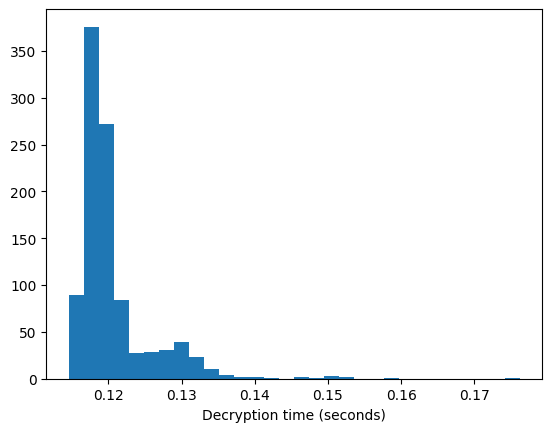

In [6]:
import secrets, time
from tqdm import tqdm
import matplotlib.pyplot as plt

N = 1100
times = []
for i in tqdm(range(N)):
    random_ciphertext = secrets.token_bytes(len(ciphertext))
    # Generate a valid ciphertext
    random_message = secrets.token_bytes(len(message))
    ciphertext = rsa_oaep.rsa_oaep_encrypt(random_message, n, e)
    if i % 100 == 0:
        random_ciphertext = ciphertext

    start = time.perf_counter()
    decrypted_message = rsa_oaep.rsa_oaep_decrypt(random_ciphertext, n, d)
    end = time.perf_counter()
    if i >= 100:
        times.append(end - start)

plt.hist(times, bins=30)
plt.xlabel("Decryption time (seconds)")

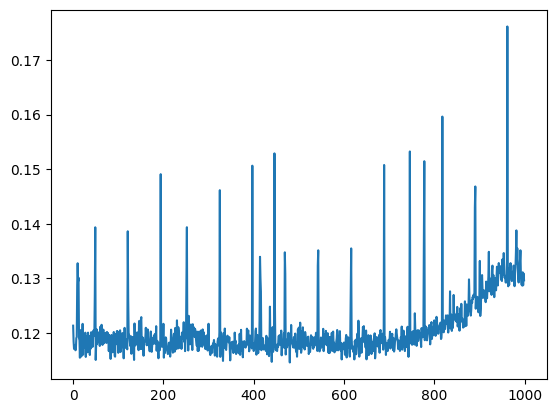

In [8]:
plt.plot(times)